In [1]:
# ring_magnetic_field_task
import kwant 
from matplotlib import pyplot as plt
from scipy.constants import physical_constants
import numpy as np
from math import atan2,pi,sqrt
import ipywidgets as widgets

In [2]:
m_el = physical_constants['electron mass'][0]
m_eff = 0.067
eV = physical_constants['electron volt'][0]
hbar = physical_constants['Planck constant over 2 pi'][0]
el_charge = physical_constants['elementary charge'][0]
hh = physical_constants['Planck constant'][0]

In [3]:
a=0.5*10**(-9)
t = hbar**2/(2*m_el*m_eff*a**2)/eV

In [4]:
def onsite(site):
    return 4*t

In [5]:
def hopping(site_0,site_1,B):
    x0,y0 = site_0.pos
    x1,y1 = site_1.pos
    C=2*np.pi*B*el_charge*10**(-18)/hh
    return -t*np.exp(-0.5j*C*(y0+y1)*(x0-x1))
    
    

In [6]:
Rmax=30
Rmin=20
Wmin=-5
Wmax=5

In [7]:
def shape(pos):
    x,y = pos
    return Rmin**2<x**2+y**2 < Rmax**2
    

In [8]:
def shape_lead(pos):
    x,y=pos
    return Wmin<y<Wmax

In [9]:
sys = kwant.Builder()
lat=kwant.lattice.square(a*10**9,norbs=1)

In [10]:
sys[lat.shape(shape,(0,Rmin+1))]=onsite

In [11]:
sys[lat.neighbors()]=hopping

In [12]:
leadl=kwant.Builder(kwant.TranslationalSymmetry((-a*10**9,0)))
leadl[lat.shape(shape_lead,(0,0))]=onsite
leadl[lat.neighbors()]=hopping

leadr=leadl.reversed()

sys.attach_lead(leadl)
sys.attach_lead(leadr)


[]

In [13]:
sysf=sys.finalized()

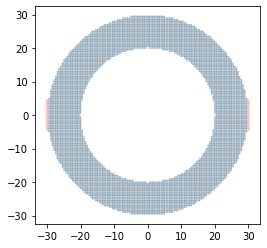

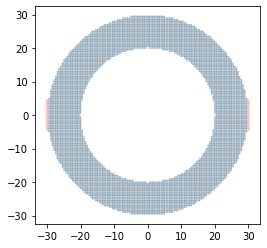

In [14]:
kwant.plot(sysf);

Task:
Calculate the transmission coeeficients for B from Bmin=0 to Bmax=7.0 (let say for N=50 values in this range). So, use the part of code we have for QPC (last classes) you will have Ttab and Btab (instead of UTab in qpc) so you need to replace U to B in this code. Plot Ttab a plot(Ttab, Utab)
